# Evaluación de modelo

Contenido:
- Visualización de detecciones (3X3) vs etiquetas: todas las cajas reales y predichas
- Matriz de confusión (clasificación de imagen)
- Metricas del modelo (Presición, sencibilidad, etc)
- Métricas de detección por objeto y mAP
- Métricas por imagen y tiempo de inferencia

## 1. Configuración e importación de módulos del proyecto

In [1]:
#!uv pip install opencv-python

In [2]:
import copy
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, multilabel_confusion_matrix
from torch.utils.data import DataLoader

### Evualuación del modelo

In [3]:
# Función para identificar la raiz del proyecto mediantes la marcha txt
def buscar_raiz_proyecto(marca='requirements.txt'):
    directorio = Path.cwd()
    for _ in range(5):
        if (directorio / marca).exists():
            return directorio
        directorio = directorio.parent
    raise FileNotFoundError('No encontre la raiz del proyecto')


RAIZ_PROYECTO = buscar_raiz_proyecto()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.append(str(RAIZ_PROYECTO))

from src.data.augmentation import get_val_transforms
from src.data.dataset import DatasetSoldadura, agrupar_lote
from src.evaluation.metricas_deteccion import emparejar_detecciones, evaluar_detecciones
from src.models.xyron_model import XyronMobileNetV2, postprocesar
from src.training.checkpoint_utils import cargar_modelo
from src.training.trainer import obtener_dispositivo

In [4]:
# Parametros de configuracion

RUTA_DATOS_TEST = RAIZ_PROYECTO / 'data_1' / 'test'
RUTA_CHECKPOINT = RAIZ_PROYECTO / 'checkpoints' / 'xyron_mnv2_fpn.pt'
IMG_SIZE = 640
NUM_CLASES = 3
NOMBRES_CLASES = ['Bad Weld', 'Good Weld', 'Defect']
UMBRAL_CLASE = 0.5
UMBRAL_CONFIANZA = 0.4
UMBRAL_CONFIANZA_MAP = 0.01
UMBRAL_IOU_NMS = 0.5
UMBRAL_IOU_EMPAREJAMIENTO = 0.5
UMBRALES_BARRIDO = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
CANTIDAD_EJEMPLOS = 9
SEMILLA = 42
BATCH_SIZE_TEST = 8
REPETICIONES_TIEMPO = 50

MEDIA_IMAGENET = np.array([0.485, 0.456, 0.406])
DESVIACION_IMAGENET = np.array([0.229, 0.224, 0.225])

## 2. Funciones auxiliares

In [5]:
def desnormalizar_imagen(tensor_imagen):
    """Deshago la normalizacion de ImageNet y devuelvo la imagen como arreglo uint8 en formato HWC."""
    imagen = tensor_imagen.cpu().numpy().transpose(1, 2, 0)
    imagen = imagen * DESVIACION_IMAGENET + MEDIA_IMAGENET
    imagen = np.clip(imagen, 0, 1)
    return (imagen * 255).astype(np.uint8)


def dibujar_caja(imagen, caja, color, texto=None, grosor=2):
    """Dibujo sobre una copia de la imagen la caja en esquinas normalizadas (x1, y1, x2, y2) con su texto opcional y devuelvo la copia."""
    alto, ancho = imagen.shape[:2]
    x1, y1, x2, y2 = caja
    x1, x2 = int(x1 * ancho), int(x2 * ancho)
    y1, y2 = int(y1 * alto), int(y2 * alto)

    copia = imagen.copy()
    cv2.rectangle(copia, (x1, y1), (x2, y2), color, grosor)
    if texto:
        cv2.putText(copia, texto, (x1 + 2, max(y1 - 4, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return copia


def etiquetas_texto(vector, nombres_clases, umbral):
    """Convierto un vector multietiqueta en el texto de las clases activas, o 'Sin clase' si ninguna supera el umbral."""
    activas = [nombre for nombre, valor in zip(nombres_clases, vector) if valor >= umbral]
    return ', '.join(activas) if activas else 'Sin clase'

In [6]:
@torch.no_grad()
def correr_inferencia(modelo, cargador, dispositivo):
    """Recorro el cargador de test y devuelvo las imagenes desnormalizadas, las clases de imagen reales y predichas, y todas las cajas reales y detectadas."""
    modelo.eval()
    imagenes_lista = []
    clases_reales = []
    clases_predichas = []
    predicciones = []
    reales = []

    for imagenes, vector_clases, _, _, cajas, clases in cargador:
        imagenes = imagenes.to(dispositivo)
        salida_clase, salida_confianza, salida_centralidad, salida_caja = modelo(imagenes)

        for indice in range(imagenes.size(0)):
            imagenes_lista.append(desnormalizar_imagen(imagenes[indice]))

        clases_reales.append(vector_clases)
        clases_predichas.append(torch.sigmoid(salida_clase).cpu())
        detecciones = postprocesar(
            salida_confianza, salida_centralidad, salida_caja, IMG_SIZE, UMBRAL_CONFIANZA_MAP, UMBRAL_IOU_NMS
        )
        predicciones += [{clave: valor.cpu() for clave, valor in deteccion.items()} for deteccion in detecciones]
        reales += [{'cajas': caja, 'clases': clase} for caja, clase in zip(cajas, clases)]

    return (
        imagenes_lista,
        torch.cat(clases_reales).numpy(),
        torch.cat(clases_predichas).numpy(),
        predicciones,
        reales,
    )

In [7]:
def graficar_cuadricula_predicciones(imagenes, predicciones, reales, cantidad, semilla):
    """Muestro una cuadricula de imagenes de test con las cajas reales detectadas en verde, las no detectadas (FN) en naranja y las predichas en rojo con su clase y confianza."""
    generador = np.random.default_rng(semilla)
    indices = generador.choice(len(imagenes), size=min(cantidad, len(imagenes)), replace=False)

    lado = int(np.ceil(np.sqrt(len(indices))))
    figura, ejes = plt.subplots(lado, lado, figsize=(5 * lado, 5 * lado))
    ejes = np.atleast_1d(ejes).flatten()

    for eje, indice in zip(ejes, indices):
        prediccion = predicciones[indice]
        real = reales[indice]
        seleccion = prediccion['puntajes'] >= UMBRAL_CONFIANZA
        cajas_predichas = prediccion['cajas'][seleccion]
        puntajes = prediccion['puntajes'][seleccion]
        clases_predichas = prediccion['clases'][seleccion]
        _, real_detectada = emparejar_detecciones(
            cajas_predichas, puntajes, clases_predichas, real['cajas'], real['clases'], UMBRAL_IOU_EMPAREJAMIENTO
        )

        imagen = imagenes[indice]
        for caja, clase, detectada in zip(real['cajas'].tolist(), real['clases'].tolist(), real_detectada.tolist()):
            color = (0, 255, 0) if detectada else (255, 165, 0)
            imagen = dibujar_caja(imagen, caja, color, NOMBRES_CLASES[clase])
        for caja, clase, puntaje in zip(cajas_predichas.tolist(), clases_predichas.tolist(), puntajes.tolist()):
            imagen = dibujar_caja(imagen, caja, (255, 0, 0), f"{NOMBRES_CLASES[clase]} {puntaje:.2f}")

        eje.imshow(imagen)
        eje.set_title(
            f"Reales: {len(real['cajas'])} | Predichas: {len(cajas_predichas)} | "
            f"No detectadas: {int((~real_detectada).sum())}",
            fontsize=9,
        )
        eje.axis('off')

    for eje in ejes[len(indices):]:
        eje.axis('off')

    figura.suptitle('Verde: real detectada | Naranja: real no detectada (FN) | Rojo: predicha', fontsize=12)
    figura.tight_layout()
    plt.show()


def graficar_matrices_confusion(reales, predichas, nombres_clases, umbral):
    """Grafico la matriz de confusion binaria de cada clase a partir de las predicciones multietiqueta."""
    predicciones_binarias = (predichas >= umbral).astype(int)
    matrices = multilabel_confusion_matrix(reales.astype(int), predicciones_binarias)

    figura, ejes = plt.subplots(1, len(nombres_clases), figsize=(5 * len(nombres_clases), 4))
    for eje, matriz, nombre in zip(ejes, matrices, nombres_clases):
        eje.imshow(matriz, cmap='Blues')
        eje.set_title(nombre)
        eje.set_xlabel('Prediccion')
        eje.set_ylabel('Real')
        eje.set_xticks([0, 1])
        eje.set_yticks([0, 1])
        eje.set_xticklabels(['Negativo', 'Positivo'])
        eje.set_yticklabels(['Negativo', 'Positivo'])
        for fila in range(2):
            for columna in range(2):
                eje.text(columna, fila, matriz[fila, columna], ha='center', va='center', fontsize=12)

    figura.tight_layout()
    plt.show()


def graficar_metricas_por_clase(reales, predichas, nombres_clases, umbral):
    """Grafico precision, sensibilidad y F1 por clase para compararlas visualmente y no solo como numeros sueltos."""
    predicciones_binarias = (predichas >= umbral).astype(int)
    reporte = classification_report(
        reales.astype(int), predicciones_binarias, target_names=nombres_clases, output_dict=True, zero_division=0
    )

    claves_sklearn = ['precision', 'recall', 'f1-score']
    etiquetas_metricas = ['Precision', 'Sensibilidad', 'F1']
    valores = np.array([[reporte[nombre][clave] for clave in claves_sklearn] for nombre in nombres_clases])

    posiciones = np.arange(len(nombres_clases))
    ancho_barra = 0.25

    figura, eje = plt.subplots(figsize=(8, 5))
    for indice, etiqueta in enumerate(etiquetas_metricas):
        eje.bar(posiciones + indice * ancho_barra, valores[:, indice], ancho_barra, label=etiqueta)

    eje.set_xticks(posiciones + ancho_barra)
    eje.set_xticklabels(nombres_clases)
    eje.set_ylim(0, 1.05)
    eje.set_ylabel('Valor')
    eje.set_title('Metricas por clase')
    eje.legend()
    figura.tight_layout()
    plt.show()

    return reporte


def graficar_metricas_deteccion(metricas, nombres_clases):
    """Grafico precision, sensibilidad, F1 y AP@0.5 por clase de la deteccion por objeto, e imprimo la tabla con TP, FP y FN."""
    valores = np.stack([
        metricas['precision_por_clase'],
        metricas['sensibilidad_por_clase'],
        metricas['f1_por_clase'],
        metricas['ap_50_por_clase'],
    ], axis=1)
    etiquetas_metricas = ['Precision', 'Sensibilidad', 'F1', 'AP@0.5']

    posiciones = np.arange(len(nombres_clases))
    ancho_barra = 0.2

    figura, eje = plt.subplots(figsize=(9, 5))
    for indice, etiqueta in enumerate(etiquetas_metricas):
        eje.bar(posiciones + indice * ancho_barra, valores[:, indice], ancho_barra, label=etiqueta)

    eje.set_xticks(posiciones + 1.5 * ancho_barra)
    eje.set_xticklabels(nombres_clases)
    eje.set_ylim(0, 1.05)
    eje.set_ylabel('Valor')
    eje.set_title(f'Deteccion por objeto (confianza >= {UMBRAL_CONFIANZA}, IoU >= {UMBRAL_IOU_EMPAREJAMIENTO})')
    eje.legend()
    figura.tight_layout()
    plt.show()

    print(f"{'Clase':<12}{'TP':>5}{'FP':>5}{'FN':>5}{'Precision':>11}{'Sensib.':>9}{'F1':>7}{'AP@0.5':>8}")
    for indice, nombre in enumerate(nombres_clases):
        print(
            f"{nombre:<12}{metricas['verdaderos_positivos'][indice]:>5}{metricas['falsos_positivos'][indice]:>5}"
            f"{metricas['falsos_negativos'][indice]:>5}{valores[indice, 0]:>11.3f}{valores[indice, 1]:>9.3f}"
            f"{valores[indice, 2]:>7.3f}{valores[indice, 3]:>8.3f}"
        )
    print(f"\nmAP@0.5: {metricas['map_50']:.4f} | mAP@0.5:0.95: {metricas['map_50_95']:.4f}")
    print(f"Precision global: {metricas['precision_global']:.4f} | Sensibilidad global: {metricas['sensibilidad_global']:.4f}")


def barrido_umbral_confianza(predicciones, reales, umbrales):
    """Recorro varios umbrales de confianza para ver con cual se alcanza la precision objetivo del proyecto (>= 85 %) sin perder demasiada sensibilidad."""
    print(f"{'Umbral':>7}{'Precision':>11}{'Sensib.':>9}{'F1 macro':>10}{'Completas':>11}")
    for umbral in umbrales:
        metricas = evaluar_detecciones(predicciones, reales, NUM_CLASES, umbral)
        print(
            f"{umbral:>7.2f}{metricas['precision_global']:>11.3f}{metricas['sensibilidad_global']:>9.3f}"
            f"{metricas['f1_macro']:>10.3f}{metricas['imagenes_completas']:>11.3f}"
        )


@torch.no_grad()
def medir_tiempo_inferencia(modelo, dispositivo, repeticiones):
    """Mido el tiempo medio por imagen (modelo + postproceso) con lote de 1, despues de un calentamiento para no contar la inicializacion."""
    modelo.eval()
    imagen = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=dispositivo)

    for _ in range(10):
        _, salida_confianza, salida_centralidad, salida_caja = modelo(imagen)
        postprocesar(salida_confianza, salida_centralidad, salida_caja, IMG_SIZE, UMBRAL_CONFIANZA, UMBRAL_IOU_NMS)

    if dispositivo.type == 'cuda':
        torch.cuda.synchronize()
    inicio = time.perf_counter()
    for _ in range(repeticiones):
        _, salida_confianza, salida_centralidad, salida_caja = modelo(imagen)
        postprocesar(salida_confianza, salida_centralidad, salida_caja, IMG_SIZE, UMBRAL_CONFIANZA, UMBRAL_IOU_NMS)
    if dispositivo.type == 'cuda':
        torch.cuda.synchronize()

    return (time.perf_counter() - inicio) / repeticiones * 1000

## 3. Carga del modelo y del conjunto de test

In [8]:
dispositivo = obtener_dispositivo()

dataset_test = DatasetSoldadura(str(RUTA_DATOS_TEST), NUM_CLASES, get_val_transforms(IMG_SIZE), IMG_SIZE)
cargador_test = DataLoader(dataset_test, batch_size=BATCH_SIZE_TEST, shuffle=False, collate_fn=agrupar_lote)

modelo = XyronMobileNetV2(NUM_CLASES).to(dispositivo)
epoca, metricas_entrenamiento = cargar_modelo(modelo, None, str(RUTA_CHECKPOINT), dispositivo)

print(f"Dispositivo: {dispositivo}")
print(f"Checkpoint de la epoca {epoca} | metricas de validacion guardadas: {metricas_entrenamiento}")
print(f"Imagenes de test: {len(dataset_test)}")

Dispositivo: cuda
Checkpoint de la epoca 44 | metricas de validacion guardadas: {'perdida_validacion': 3.516218746515145, 'f1_macro': 0.7567882537841797, 'map_50': 0.42259365447255187, 'map_50_95': 0.16532445944933893, 'f1_macro_objetos': 0.4648853427389703, 'precision_objetos': 0.42777777777777776, 'sensibilidad_objetos': 0.5384615384615384, 'descongelar_desde': 7}
Imagenes de test: 56


In [9]:
imagenes, clases_reales, clases_predichas, predicciones, reales = correr_inferencia(
    modelo, cargador_test, dispositivo
)

## 4. Visualización de detecciones (3x3) vs etiquetas reales

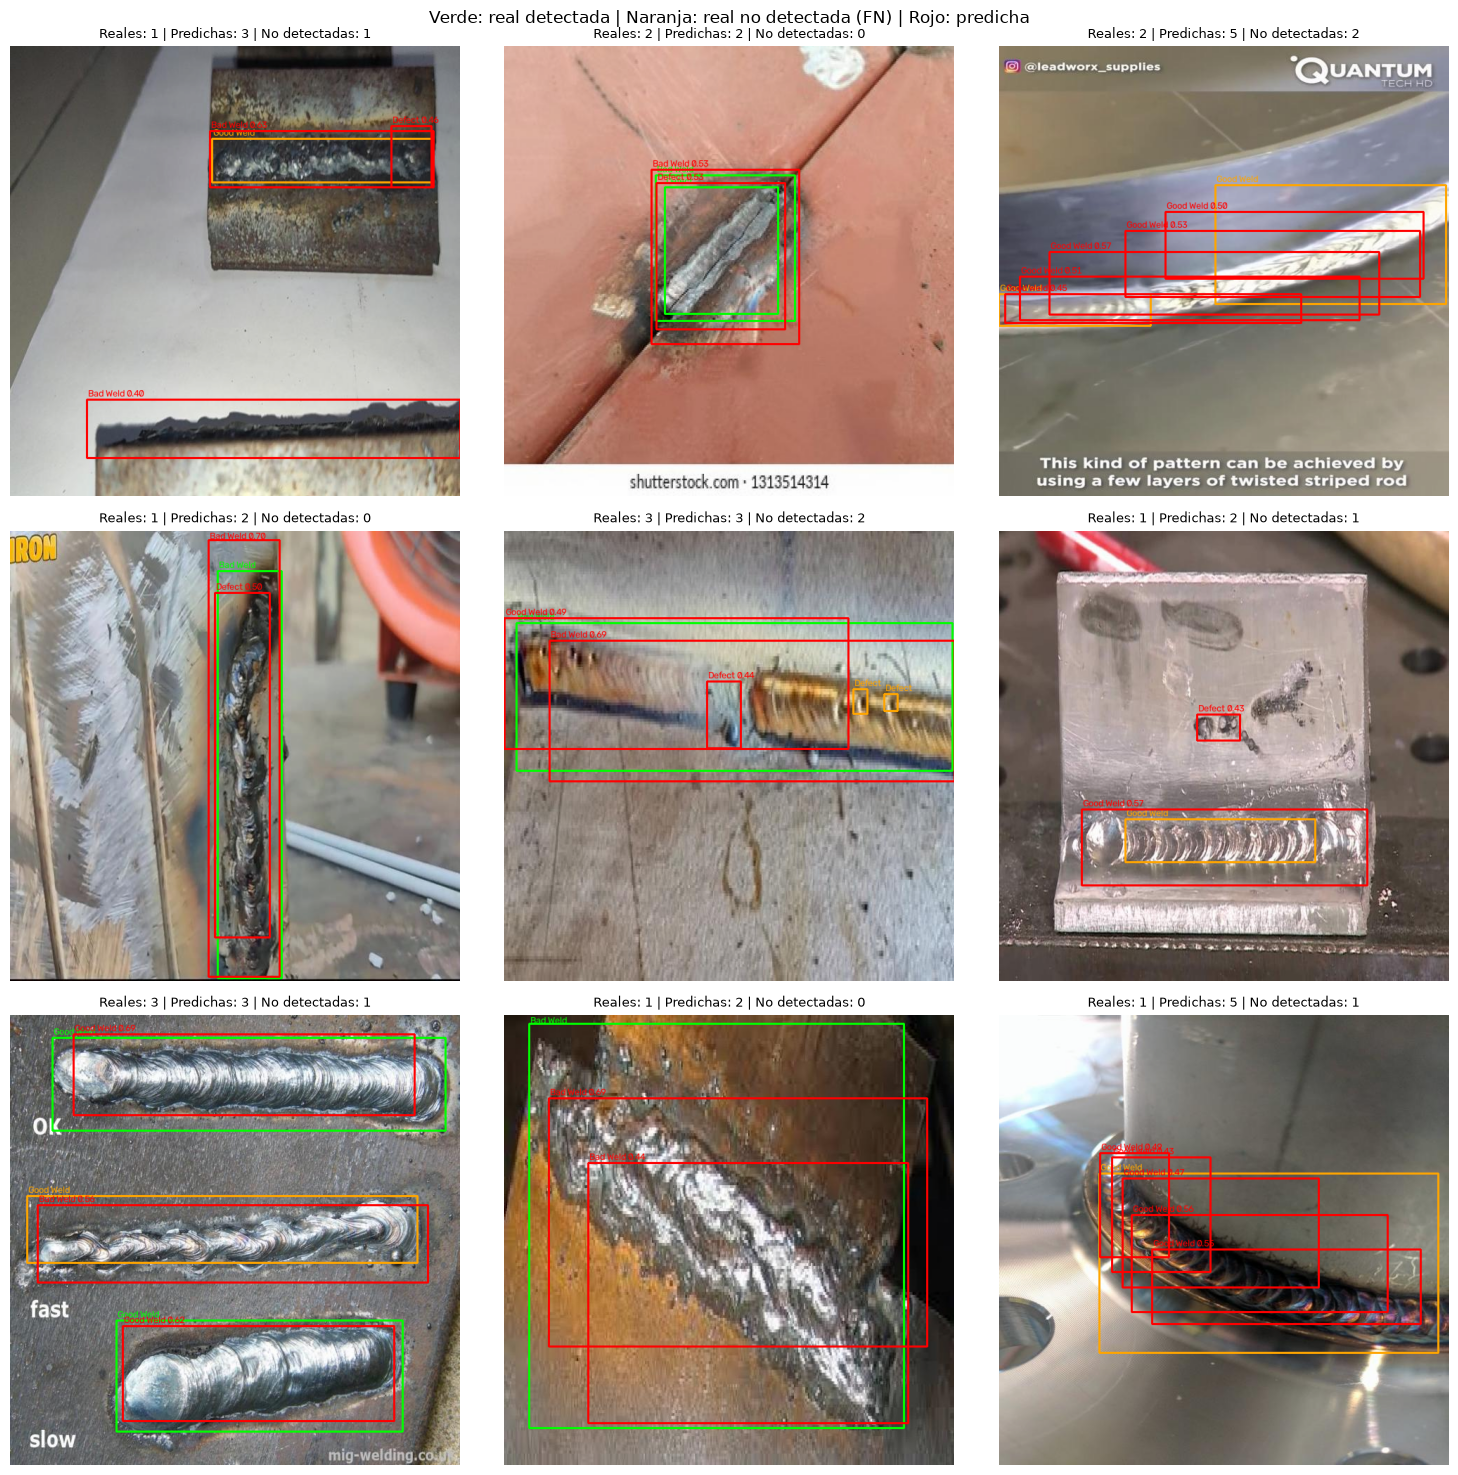

In [10]:
graficar_cuadricula_predicciones(imagenes, predicciones, reales, CANTIDAD_EJEMPLOS, SEMILLA)

## 5. Matriz de confusión por clase (clasificación de imagen)

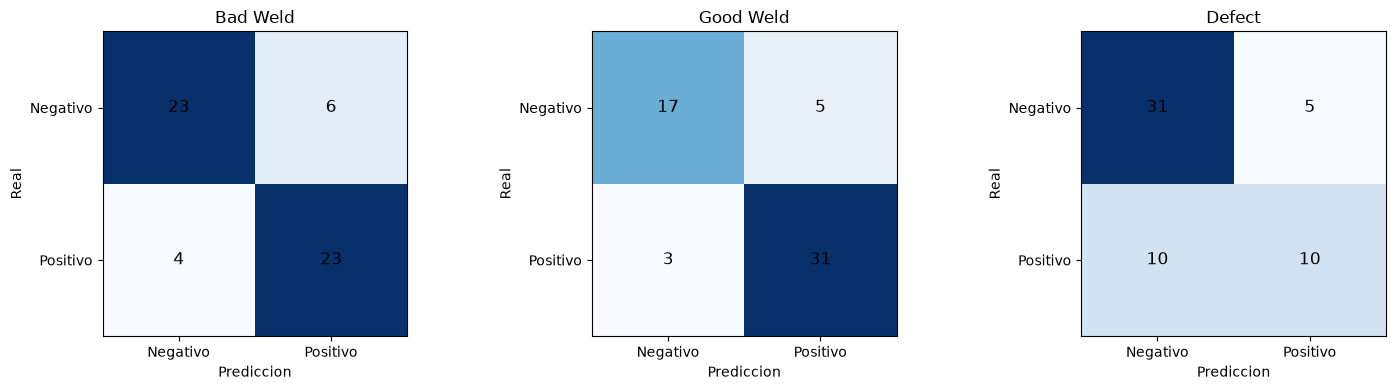

In [11]:
graficar_matrices_confusion(clases_reales, clases_predichas, NOMBRES_CLASES, UMBRAL_CLASE)


## 6. Métricas de clasificación de imagen (precisión, sensibilidad, F1)

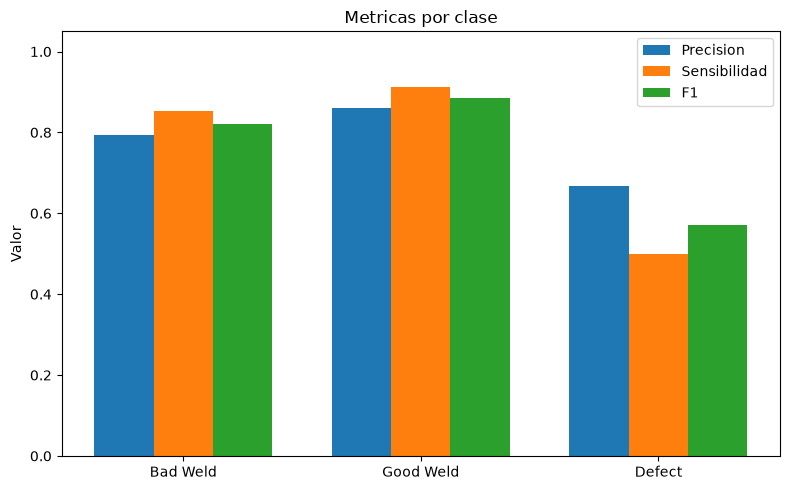

              precision    recall  f1-score   support

    Bad Weld       0.79      0.85      0.82        27
   Good Weld       0.86      0.91      0.89        34
      Defect       0.67      0.50      0.57        20

   micro avg       0.80      0.79      0.80        81
   macro avg       0.77      0.75      0.76        81
weighted avg       0.79      0.79      0.79        81
 samples avg       0.79      0.79      0.77        81



In [12]:
reporte = graficar_metricas_por_clase(clases_reales, clases_predichas, NOMBRES_CLASES, UMBRAL_CLASE)

predicciones_binarias = (clases_predichas >= UMBRAL_CLASE).astype(int)
print(classification_report(
    clases_reales.astype(int), predicciones_binarias, target_names=NOMBRES_CLASES, zero_division=0
))


## 7. Métricas de detección por objeto (precisión, sensibilidad, F1 y mAP)

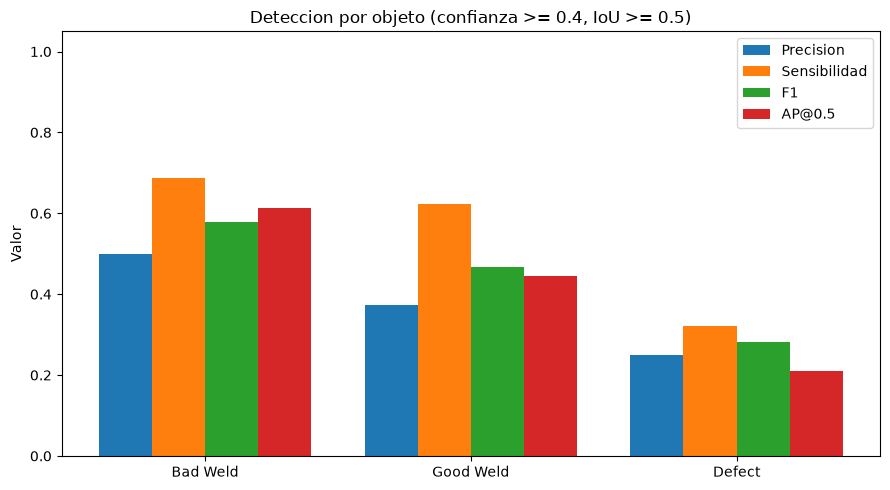

Clase          TP   FP   FN  Precision  Sensib.     F1  AP@0.5
Bad Weld       22   22   10      0.500    0.688  0.579   0.613
Good Weld      28   47   17      0.373    0.622  0.467   0.444
Defect          9   27   19      0.250    0.321  0.281   0.211

mAP@0.5: 0.4226 | mAP@0.5:0.95: 0.1763
Precision global: 0.3806 | Sensibilidad global: 0.5619


In [13]:
metricas_deteccion = evaluar_detecciones(predicciones, reales, NUM_CLASES, UMBRAL_CONFIANZA)
graficar_metricas_deteccion(metricas_deteccion, NOMBRES_CLASES)

In [14]:
barrido_umbral_confianza(predicciones, reales, UMBRALES_BARRIDO)

 Umbral  Precision  Sensib.  F1 macro  Completas


   0.20      0.075    0.705     0.182      0.589


   0.30      0.195    0.619     0.327      0.518


   0.40      0.381    0.562     0.442      0.482


   0.50      0.557    0.419     0.431      0.393


   0.60      0.784    0.276     0.348      0.214


   0.70      0.800    0.038     0.053      0.054


   0.80      0.000    0.000     0.000      0.000


## 8. Métricas por imagen

In [15]:
print(f"Imagenes con todas las soldaduras detectadas: {metricas_deteccion['imagenes_completas'] * 100:.1f} %")
print(f"Error de conteo medio |predichas - reales|: {metricas_deteccion['error_conteo_medio']:.2f} cajas por imagen")

Imagenes con todas las soldaduras detectadas: 48.2 %
Error de conteo medio |predichas - reales|: 1.14 cajas por imagen


## 9. Tiempo de inferencia (objetivo < 500 ms por imagen)

In [16]:
tiempo_dispositivo = medir_tiempo_inferencia(modelo, dispositivo, REPETICIONES_TIEMPO)
print(f"Tiempo medio en {dispositivo}: {tiempo_dispositivo:.1f} ms por imagen")

if dispositivo.type != 'cpu':
    modelo_cpu = copy.deepcopy(modelo).to('cpu')
    tiempo_cpu = medir_tiempo_inferencia(modelo_cpu, torch.device('cpu'), REPETICIONES_TIEMPO)
    print(f"Tiempo medio en cpu: {tiempo_cpu:.1f} ms por imagen")

Tiempo medio en cuda: 15.9 ms por imagen


Tiempo medio en cpu: 216.6 ms por imagen
